In [1]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
import pickle

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [4]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
seed = 1111
set_seed(seed)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(no_aug_synth_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed1111_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

synth_feats_accum, synth_labels_accum = [], []

for epoch in range(200):
    with torch.no_grad():
        for inputs, targets in tqdm(DataLoader(
            synth_ds, batch_size = 64, 
            shuffle = False, num_workers = 6,
            pin_memory = True, persistent_workers=True, prefetch_factor = 4,
            worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)
            ), leave = False):
            
            inputs = inputs.to(device)
            feats = feature_extractor(inputs)
            feats = feats.view(feats.size(0), -1)
            synth_feats_accum.append(feats.cpu())
            synth_labels_accum.append(targets)

meas_feats, meas_labels = [], []
with torch.no_grad():
    for inputs, targets in tqdm(DataLoader(
            meas_ds, batch_size = 64, 
            shuffle = False, num_workers = 6,
            pin_memory = True, persistent_workers=True, prefetch_factor = 4,
            worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)
            ), leave = False):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        meas_feats.append(feats.cpu())
        meas_labels.append(targets)

meas_feats  = torch.cat(meas_feats).numpy()
meas_labels = torch.cat(meas_labels).numpy()

In [6]:
synth_feats  = torch.cat(synth_feats_accum).numpy()
synth_labels = torch.cat(synth_labels_accum).numpy()

In [10]:
combined_feats  = np.concatenate([synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([synth_labels, meas_labels], axis=0)

# Global UMAP

In [17]:
reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
    metric = "cosine"
)

features_2d = reducer.fit_transform(combined_feats)

[2026-05-19 04:33:18.466] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-05-19 04:33:18.469] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.


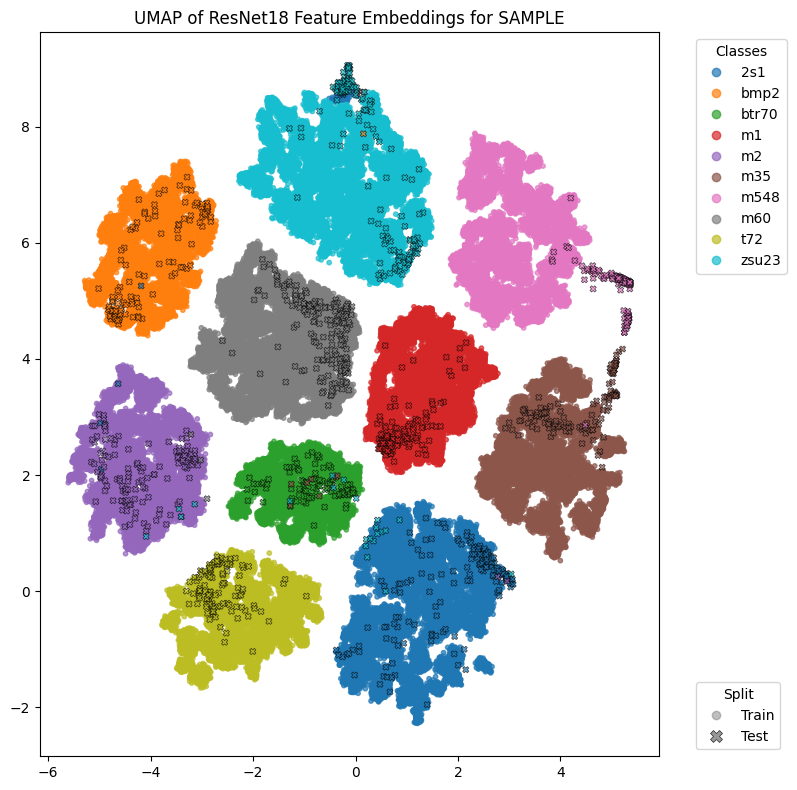

In [24]:
# Get class names from the dataset
class_names = [name for name, idx in sorted(no_aug_synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(synth_feats), 0],
    features_2d[:len(synth_feats), 1],
    c=combined_labels[:len(synth_feats)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(synth_feats):, 0],
    features_2d[len(synth_feats):, 1],
    c=combined_labels[len(synth_feats):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Train"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Test"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

# Class UMAPs

[2026-05-19 04:55:19.730] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


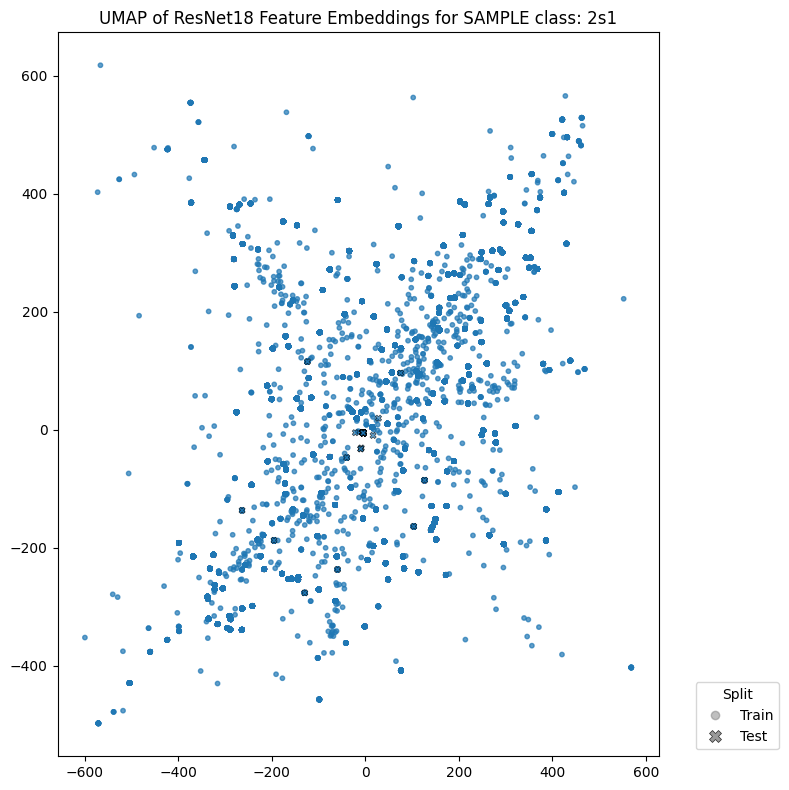

[2026-05-19 04:55:20.981] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


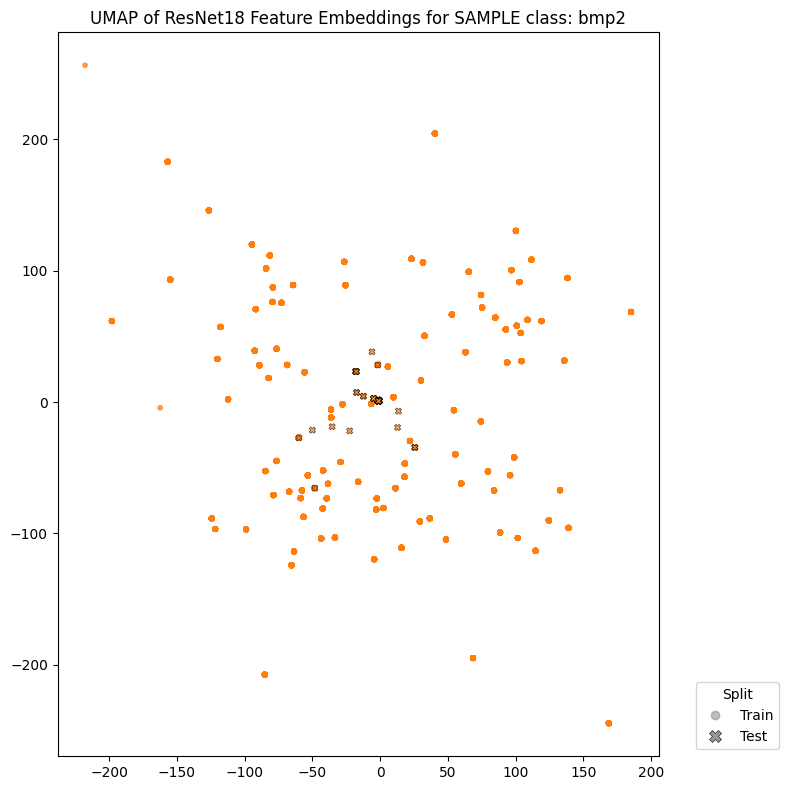

[2026-05-19 04:55:21.837] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


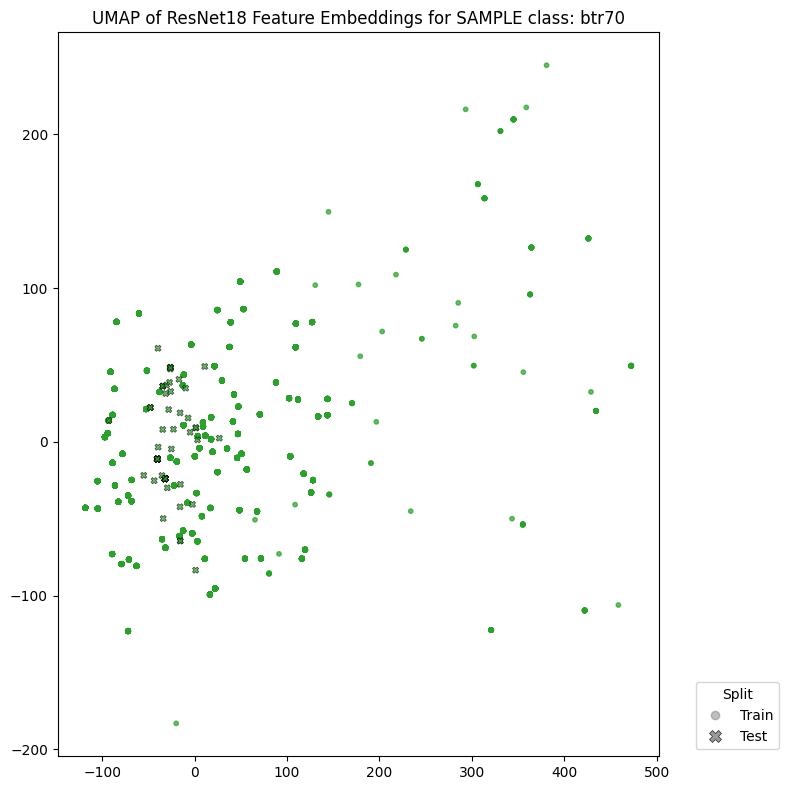

[2026-05-19 04:55:22.446] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


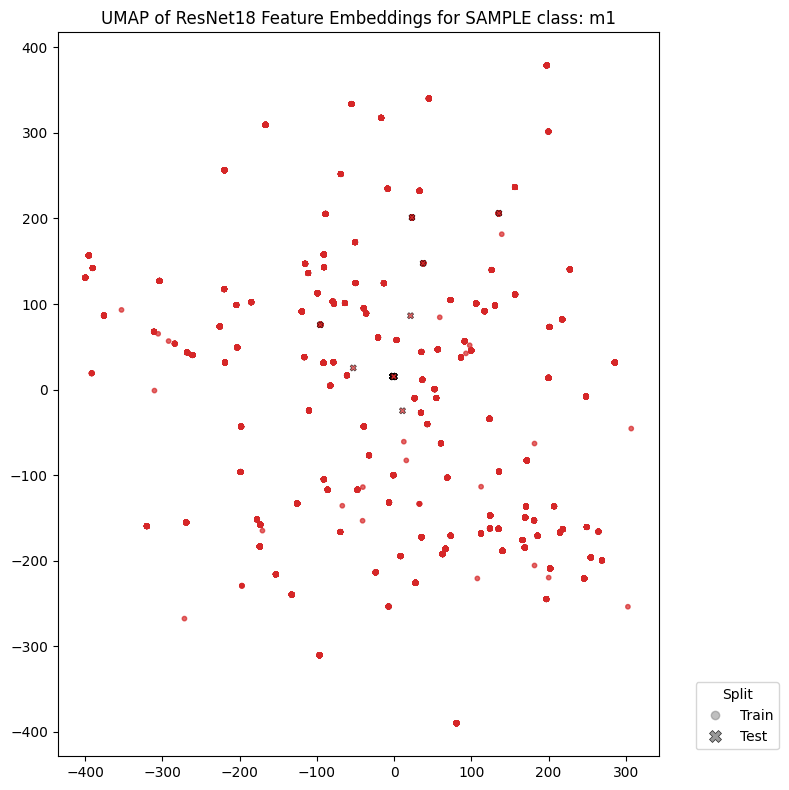

[2026-05-19 04:55:23.335] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


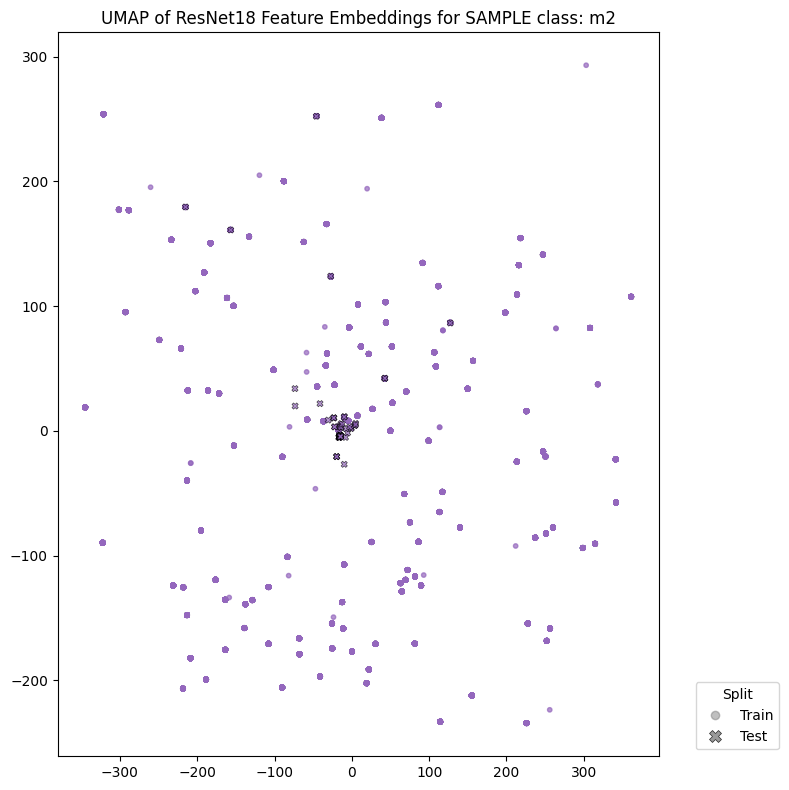

[2026-05-19 04:55:24.231] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


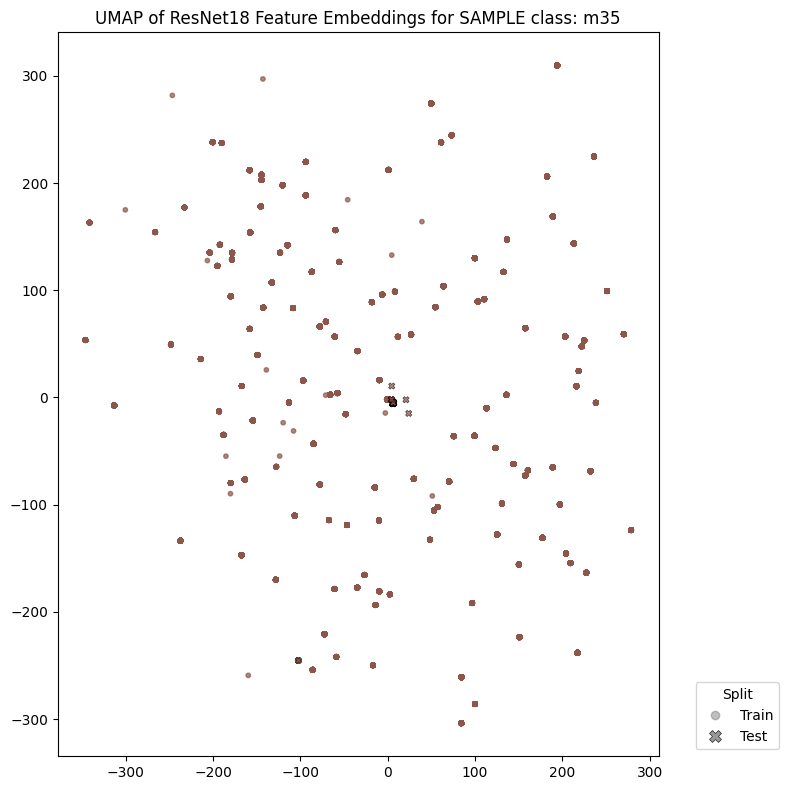

[2026-05-19 04:55:25.359] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


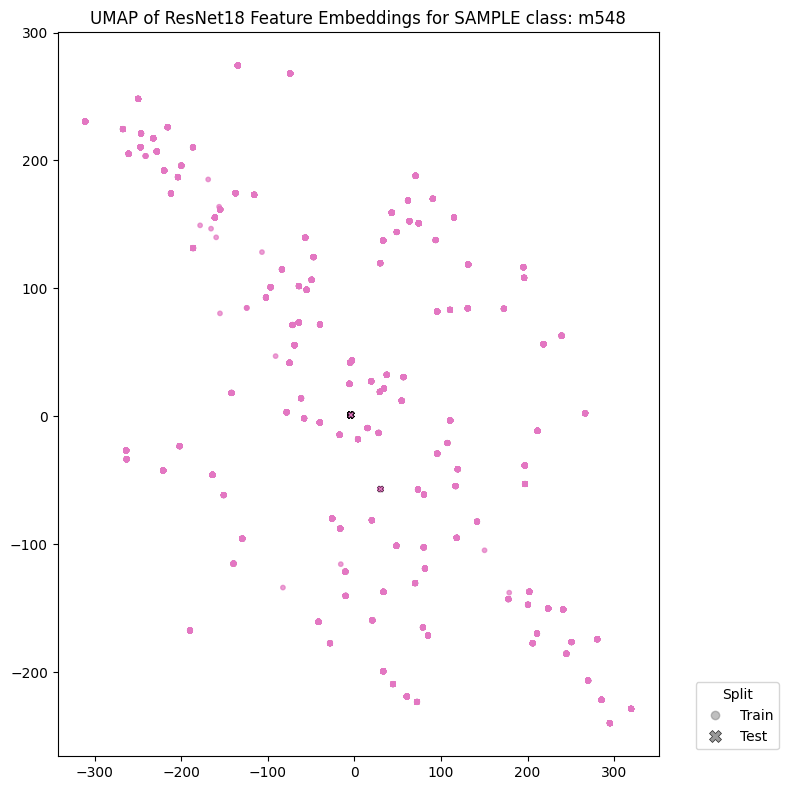

[2026-05-19 04:55:26.342] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


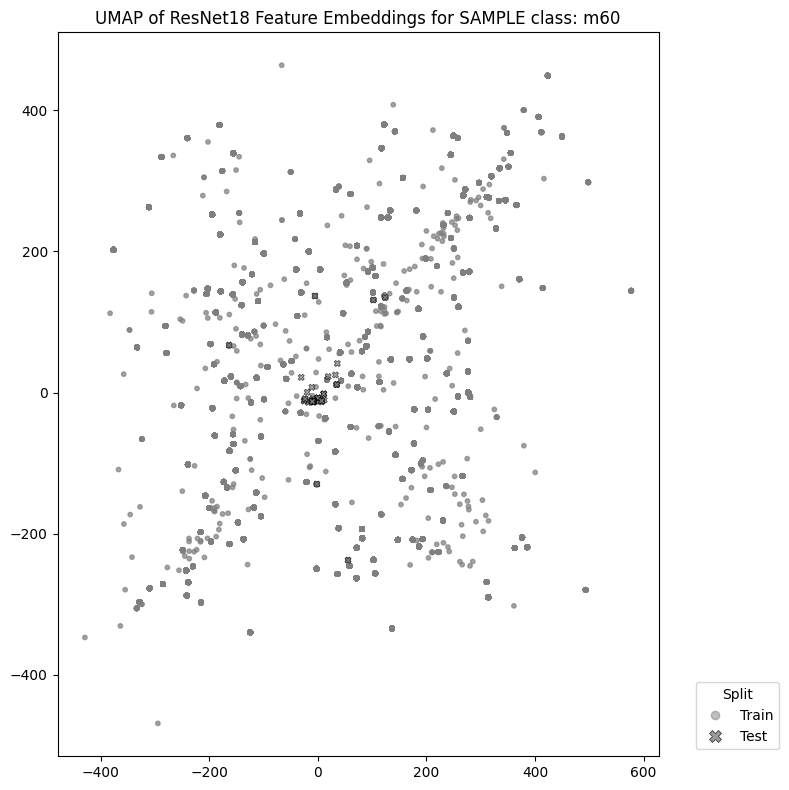

[2026-05-19 04:55:27.419] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


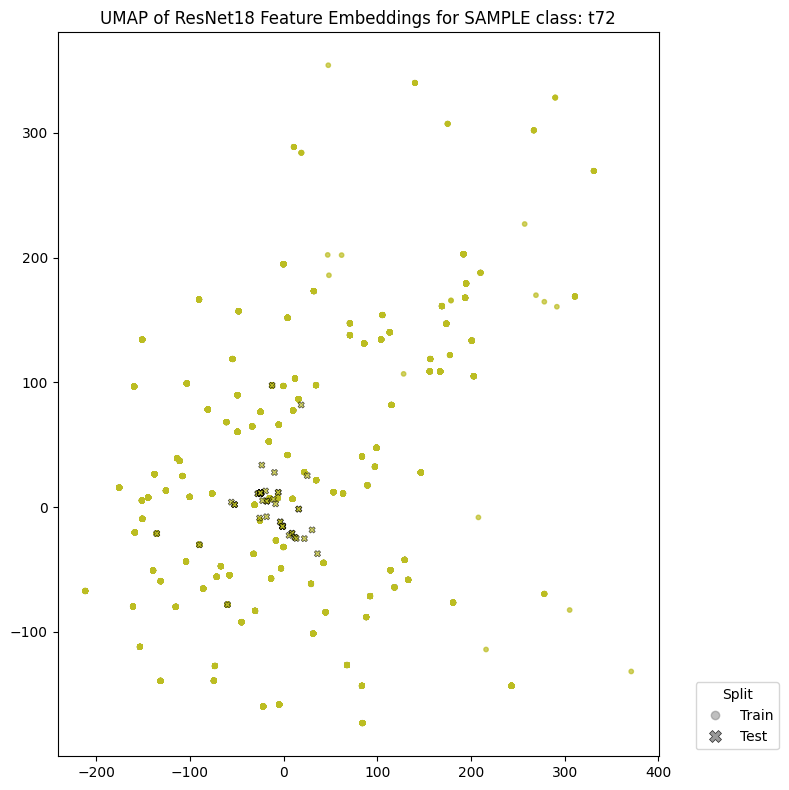

[2026-05-19 04:55:28.241] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


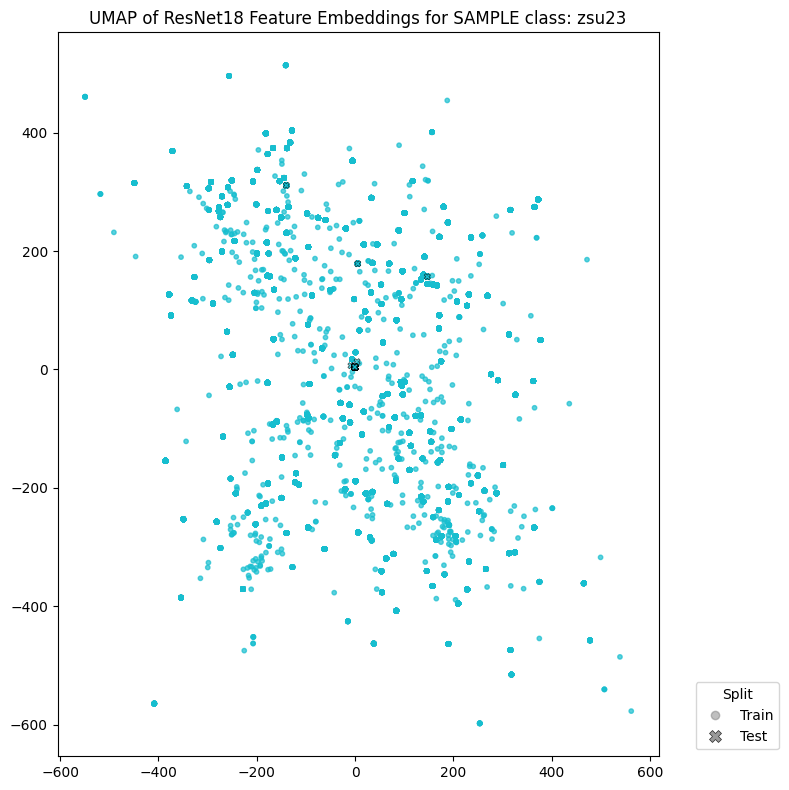

In [34]:
for i in range(len(no_aug_synth_ds.classes)):
    class_synth_feats = synth_feats[synth_labels == i]
    class_synth_labels = synth_labels[synth_labels == i]

    class_meas_feats = meas_feats[meas_labels == i]
    class_meas_labels = meas_labels[meas_labels == i]

    class_combined_feats = np.concatenate([class_synth_feats, class_meas_feats], axis = 0)
    class_combined_labels = np.concatenate([class_synth_labels, class_meas_labels], axis = 0)
    
    reducer = UMAP(
        n_neighbors=100,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )
    
    features_2d = reducer.fit_transform(class_combined_feats)

    # Get class names from the dataset
    class_names = [name for name, idx in sorted(no_aug_synth_ds.class_to_idx.items(), key=lambda x: x[1])]
    
    n_classes = len(class_names)
    
    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d[:len(class_synth_feats), 0],
        features_2d[:len(class_synth_feats), 1],
        c=class_combined_labels[:len(class_synth_feats)],
        cmap="tab10",
        s=10,
        alpha=0.7,
        marker = "o",
        vmin=0, vmax=n_classes - 1
    )
    
    plt.scatter(
        features_2d[len(class_synth_feats):, 0],
        features_2d[len(class_synth_feats):, 1],
        c=class_combined_labels[len(class_synth_feats):],
        cmap="tab10",
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k",
        vmin=0, vmax=n_classes - 1
    )
    
    # class_legend = plt.legend(
    #     handles=scatter.legend_elements()[0],
    #     labels=class_names,
    #     title="Classes",
    #     bbox_to_anchor=(1.05, 1),
    #     loc="upper left"
    # )
    
    # fig.add_artist(class_legend)  # keep it when adding the second legend
    
    # Marker legend for train vs test
    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Train"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Test"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")
    
    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE class: {no_aug_synth_ds.classes[i]}")
    plt.tight_layout()
    plt.show()